![WEkEO by Copernicus and Partners](./img/WEkEO_banner_partners.png)

# WEKEO TRAINING

<div style="text-align: right"><i>  </i></div>

***
<center><h1> Monitoring Land Artificialization around the Poznań Metropolitan Area </h1></center>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Run" and select "Run All Above Selected Cell".<br>

**General Note 3**: To explore more (Python and R) content, there is our [**Jupyter Catalogue**](https://notebooks.apps.mercator.dpi.wekeo.eu/), and if you seek support, there are plenty of useful resources in our [**Help Center**](https://help.wekeo.eu/en/). Feel free to contact us using our [**live chat widget**](https://www.wekeo.eu/support) or by email at [support@wekeo.eu](mailto:support@wekeo.eu)! <br>

***

**PREREQUISITES**

This notebook has the following prerequisites:
- [A WEkEO account](https://my.wekeo.eu/user-registration) if you are using or plan to use WEkEO.

**LEARNING OUTCOMES**

At the end of this notebook you will know:

- How to use the WEkEO HDA client to programmatically fetch Copernicus Land Monitoring Service products.
- How to manipulate vector land-cover data (Urban Atlas) with GeoPandas.
- How to rasterize vector layers and build a land-cover transition matrix to quantify artificialization between two dates.
- How to compute simple landscape ecology indicators (fragmentation, patch connectivity, corridor friction) to assess the impact of urban sprawl on ecological networks.

# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Setting up the Python environment](#2.-Setting-up-the-Python-environment)
    - [2.1 Required Python modules](#2.1-Required-Python-modules)
    - [2.2 Utility functions](#2.2-Utility-functions)
    - [2.3 Setup the WEkEO HDA and Credentials](#2.3-Setup-the-WEkEO-HDA-and-Credentials)
- [3. Data Download](#3.-Data-Download)
    - [3.1. Presentation of the product used](#3.1.-Presentation-of-the-product-used)
    - [3.2. Downloading the Urban Atlas 2012 data](#3.2.-Downloading-the-Urban-Atlas-2012-data)
    - [3.3. Downloading the Urban Atlas 2018 data](#3.3.-Downloading-the-Urban-Atlas-2018-data)
- [4. Preparing the Urban Atlas datasets](#4.-Preparing-the-Urban-Atlas-datasets)
- [5. Mapping land-cover change (2012 to 2018)](#5.-Mapping-land-cover-change-(2012-to-2018))
- [6. Landscape fragmentation indicators](#6.-Landscape-fragmentation-indicators)
- [7. Ecological connectivity: modelling the green network](#7.-Ecological-connectivity:-modelling-the-green-network)
- [8. Exercises](#8.-Exercises)
- [9. MCQ](#9.-MCQ)
- [10. Conclusion](#10.-Conclusion)

## 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

Land artificialization, the conversion of agricultural, forest or semi-natural land into built-up surfaces, is one of the most direct and visible signatures of urban growth. Unlike many climate indicators, it is not a slow, diffuse process observed at global scale: it happens parcel by parcel, at the edge of every growing city, and it has immediate consequences on biodiversity, water infiltration, local climate (urban heat islands) and the fragmentation of natural habitats.

**Poznań**, the fifth largest city in Poland and the capital of the Wielkopolska region, is an example of a fast-growing Central European city. Since the early 2000s, its metropolitan area has experienced strong residential and logistical sprawl, driven by suburbanization, new transport infrastructure and industrial development around the historic core. This makes it an excellent case study to illustrate how Earth observation data can be used to monitor urban sprawl.

The **Copernicus Land Monitoring Service (CLMS)**, accessible through **WEkEO**, provides exactly the kind of high-resolution, multi-temporal products needed for this task. In this notebook we focus on **Urban Atlas**, a detailed vector land-use/land-cover database produced for European Functional Urban Areas at several reference years — here 2012 and 2018 for the Poznań Functional Urban Area.

Starting from these two Urban Atlas vintages, we will:

1. Quantify how much land was artificialized around Poznań between 2012 and 2018, and locate *where* this happened;
2. Assess the impact of this artificialization on landscape fragmentation and on the connectivity of the remaining forest patches (a simple proxy for a "green network" or ecological corridor system).

By the end of this notebook, you will have built, step by step, a small geospatial analysis pipeline that could be reused for any other European city covered by the Copernicus Land Monitoring Service.

## 2. Setting up the Python environment
[Go back to the "Table of contents"](#Table-of-contents)

### 2.1 Required Python modules
[Go back to the "Table of contents"](#Table-of-contents)

The Jupyter Notebook must be set up with all the necessary tools from the Python geospatial ecosystem. Here is the list of the modules we will be using in this exercise.

| Module name | Description |
| :---: | :---|
| **hda** | The [WEkEO Harmonized Data Access](https://help.wekeo.eu/en/articles/9515753-what-is-the-harmonized-data-access-hda-api) client, used to search for and download Copernicus Land Monitoring Service products. |
| **geopandas** | [GeoPandas](https://geopandas.org/) extends pandas to handle vector geospatial data (here, the Urban Atlas polygons). |
| **geocube** | [geocube](https://corteva.github.io/geocube/stable/) converts (rasterizes) vector GeoDataFrames onto a regular raster grid, which is required to compare the two Urban Atlas vintages pixel by pixel. |
| **numpy / pandas** | [NumPy](https://numpy.org/) and [pandas](https://pandas.pydata.org/) are the fundamental packages for numerical computing and tabular data manipulation. |
| **matplotlib** | [Matplotlib](https://matplotlib.org/) is used to produce all the static maps and charts. |
| **scipy.ndimage / scipy.spatial** | Used to label connected patches (landscape fragmentation) and compute distances between patch centroids (connectivity graph). |
| **networkx** | [NetworkX](https://networkx.org/) is used to build and analyse the graph representing the ecological connectivity between forest patches. |

In [1]:
# Modules system
import warnings

warnings.filterwarnings("ignore")

import getpass
import json
import os
import shutil
from pathlib import Path

import hda
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

from scipy.ndimage import label, center_of_mass
from scipy.spatial.distance import cdist

import networkx as nx

### 2.2 Utility functions

[Go back to the "Table of contents"](#Table-of-contents)

To finalize our Python environment, we define below a couple of helper objects that we will reuse several times throughout the notebook:

- `map_ua_code_to_class`: a function that simplifies the (very detailed) Urban Atlas nomenclature into 4 broad classes that are easier to visualize and compare;
- `class_code_map` / `simple_class_colors`: a shared numeric coding and a shared color palette for these 4 classes, so that every map in the notebook uses the same colors.

In [2]:
def map_ua_code_to_class(code):
    """
    Map the (numeric or string) Urban Atlas nomenclature code to one of
    4 simplified land-cover classes.
    """
    code_str = str(code).strip()
    if code_str.startswith("1"):
        return "1. Urban / Artificial"
    elif code_str.startswith("2"):
        return "2. Agricultural / Grassland"
    elif code_str.startswith("3"):
        return "3. Forest / Semi-natural"
    elif code_str.startswith(("4", "5")):
        return "4. Wetlands / Water"
    else:
        return "Not classified"

In [3]:
# Numeric code used later on to rasterize the simplified classes
class_code_map = {
    "1. Urban / Artificial": 1,
    "2. Agricultural / Grassland": 2,
    "3. Forest / Semi-natural": 3,
    "4. Wetlands / Water": 4,
}

# A single color palette reused for every map of the 4 simplified classes
# Red, Yellow, Green, Blue
simple_class_colors = ["#d73027", "#fee08b", "#1a9850", "#4575b4"]
cmap_simple_classes = ListedColormap(simple_class_colors)

### 2.3 Setup the WEkEO HDA and Credentials

[Go back to the "Table of contents"](#Table-of-contents)

To download products from the [WEkEO Data Catalogue](https://www.wekeo.eu/data), we will use the WEkEO [Harmonized Data Access (HDA) client](https://help.wekeo.eu/en/articles/9515753-what-is-the-harmonized-data-access-hda-api).
If you are currently working on the WEkEO JupyterHub, this client should already be installed. Otherwise, you can use the environment file included in this repository (`environment.yml`) to build your own Python environment (as detailed in the README) and install it. You are also welcome to view the [source code](https://github.com/ecmwf/hda) for more information and further instructions.

In order to download data using the WEkEO HDA adaptor, we need to provide our credentials. To do this, create a file called `.hdarc` in your home directory. For most systems, the home directory can be:

- `\user\username`
- `/users/username`
- `/home/username`

depending on your operating system. In this file, add the following information exactly as shown:

`user:<your_user_name>`

`password:<your_password>`

You must replace `<your_user_name>` and `<your_password>` with your WEkEO account information.
If you don't have an account yet, please register at [https://www.wekeo.eu/](https://www.wekeo.eu/).

Once these credentials are entered, the `hda` client will automatically read them from the file when you use it. Let's create our credentials file, if it doesn't already exist.

In [4]:
# load credentials
wekeo_credentials_file = Path(Path.home() / ".hdarc")


def get_credentials():
    user = input("Enter your WEkEO user name: ").strip()
    password = getpass.getpass("Enter your WEkEO password: ").strip()
    return user, password


def save_credentials(user, password):
    os.makedirs(os.path.dirname(wekeo_credentials_file), exist_ok=True)
    with open(wekeo_credentials_file, "w", encoding="utf-8") as f:
        f.write(f"user: {user}\npassword: {password}")


# Try loading saved credentials
if not wekeo_credentials_file.is_file():
    user, password = get_credentials()
    save_credentials(user, password)

In [5]:
# Try to get a token, retrying if the credentials are invalid
while True:
    try:
        token = hda.Client().token
        print("WEkEO token created.")
        break  # Exit loop if successful
    except hda.api.ConfigurationError as e:
        print("Invalid username or password. Please try again.")
        print(e)
        user, password = get_credentials()
        save_credentials(user, password)

WEkEO token created.


## 3. Data Download

[Go back to the "Table of contents"](#Table-of-contents)

### 3.1. Presentation of the product used

[Go back to the "Table of contents"](#Table-of-contents)

From the WEkEO [Data Viewer](https://www.wekeo.eu/data), you can explore all the Copernicus Land Monitoring Service products available, with many filters to select the region, reference year, and parameters you are interested in.

In this notebook, we use **Urban Atlas**, a detailed vector land-use/land-cover classification, produced for two reference years, covering the Poznań Functional Urban Area:

| Parameter | Value |
| :---: | :---|
| **Product** | Urban Atlas Land Cover / Land Use |
| **Reference years used** | 2012 and 2018 |
| **Format** | Vector (GeoPackage), detailed nomenclature |
| **Spatial extent** | Poznań Functional Urban Area (FUA) |

<center>
    <img src="img/urban_atlas_thb.png" width="200">
</center>


You can visit the [Copernicus Land Monitoring Service page](https://land.copernicus.eu/en/products/urban-atlas?tab=overview) dedicated to Urban Atlas to see more details and detailed documentation.

### 3.2. Downloading the Urban Atlas 2012 data

[Go back to the "Table of contents"](#Table-of-contents)

The WEkEO HDA client accepts requests as JSON queries. These have a specific format, which may look complex, but you can build on the examples you can find in the [Data Viewer](https://www.wekeo.eu/data), available under the **Show API request** button.

![WEkEO by Copernicus and Partners](./img/data_req.png)

Let's start by creating our HDA client, then load and inspect the JSON request for the 2012 Urban Atlas vintage.

In [6]:
# HDA client, reused for every search/download in this notebook
c = hda.Client()
output_path = "data"

In [7]:
# Loading the 2012 Urban Atlas request from a JSON file
with open("./data/req_ua_2012.json", "r") as f:
    query_ua_2012 = json.load(f)
query_ua_2012

{'dataset_id': 'EO:EEA:DAT:URBAN-ATLAS',
 'productType': 'Urban Atlas 2012',
 'version': 'v021',
 'itemsPerPage': 200,
 'startIndex': 0}

The data request will yield **all** the cities available in the 2012 Urban Atlas. Therefore, we specify the targeted city name to make sure there is a dataset dedicated to Poznan available.

In [8]:
# Running the search for the 2012 Urban Atlas product
matches_2012 = c.search(query_ua_2012)

city = "POZNAN"

# Looking for the result whose file name matches our city of interest
match_ind_2012 = None
for i, match in enumerate(matches_2012.results):
    fdst = f"{match['id']}"
    if city in fdst:
        match_ind_2012 = i
        print(f"Found: {fdst}")

Found: ua2012_PL005L2_POZNAN_UA2012_revised_v021


We've found it, we can now download the data.

In [ ]:
matches_2012[match_ind_2012].download(output_path)

### 3.3. Downloading the Urban Atlas 2018 data

[Go back to the "Table of contents"](#Table-of-contents)

We repeat the same three steps (load request, search, download) for the 2018 vintage.

In [9]:
# Loading the 2018 Urban Atlas request from a JSON file
with open("./data/req_ua_2018.json", "r") as f:
    query_ua_2018 = json.load(f)
query_ua_2018

{'dataset_id': 'EO:EEA:DAT:URBAN-ATLAS',
 'productType': 'Urban Atlas 2018',
 'version': 'Unspecified',
 'itemsPerPage': 200,
 'startIndex': 0}

In [11]:
# Running the search for the 2018 Urban Atlas product
matches_2018 = c.search(query_ua_2018)

match_ind_2018 = None
for i, match in enumerate(matches_2018.results):
    fdst = f"{match['id']}"
    if city in fdst:
        match_ind_2018 = i
        print(f"Found: {fdst}")

Found: ua2018_PL005L2_POZNAN_UA2018_v013


In [ ]:
matches_2018[match_ind_2018].download(output_path)

## 4. Preparing the Urban Atlas datasets

[Go back to the "Table of contents"](#Table-of-contents)

We have downloaded the Urban Atlas archives for both reference years. Let's now unpack them and load the vector layers with **GeoPandas**.

In [10]:
# Unpacking the 2012 and 2018 Urban Atlas archives
shutil.unpack_archive(
    os.path.join(output_path, "ua2012_PL005L2_POZNAN_UA2012_revised_v021.zip"),
    os.path.join(output_path),
)

shutil.unpack_archive(
    os.path.join(output_path, "ua2018_PL005L2_POZNAN_UA2018_v013.zip"),
    os.path.join(output_path),
)

In [7]:
# Loading the 2012 vector layer
gdf_2012 = gpd.read_file(
    os.path.join(
        output_path,
        "PL005L2_POZNAN_UA2012_revised_v021/Data/PL005L2_POZNAN_UA2012_revised_v021.gpkg",
    )
)
gdf_2012.head()

,country,fua_name,fua_code,code_2012,class_2012,prod_date,identifier,perimeter,area,comment,Pop2012,geometry
0,PL,Poznań,PL005L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,2020-09,7897-PL005L2,7943.010926,2.527190e+05,None,5665,"MULTIPOLYGON (((4789722.593 3283915.574, 47897..."
1,PL,Poznań,PL005L2,21000,Arable land (annual crops),2020-09,20801-PL005L2,7134.884297,5.819750e+05,None,15,"MULTIPOLYGON (((4791757.325 3240982.401, 47916..."
2,PL,Poznań,PL005L2,21000,Arable land (annual crops),2020-09,20823-PL005L2,9607.091670,1.572687e+06,None,1,"MULTIPOLYGON (((4784398.037 3242491.984, 47844..."
3,PL,Poznań,PL005L2,21000,Arable land (annual crops),2020-09,20944-PL005L2,4055.911155,3.318314e+05,None,0,"MULTIPOLYGON (((4787646.888 3246386.133, 47876..."
4,PL,Poznań,PL005L2,21000,Arable land (annual crops),2020-09,40215-PL005L2,33766.508938,3.004308e+06,None,0,"MULTIPOLYGON (((4788588.33 3249235.8, 4788586...."


In [8]:
# Loading the 2018 vector layer
gdf_2018 = gpd.read_file(
    os.path.join(
        output_path, "PL005L2_POZNAN_UA2018_v013/Data/PL005L2_POZNAN_UA2018_v013.gpkg"
    )
)
gdf_2018.head()

,country,fua_name,fua_code,code_2018,class_2018,prod_date,identifier,perimeter,area,comment,Pop2018,geometry
0,PL,Poznań,PL005L2,11100,Continuous urban fabric (S.L. : > 80%),2020-09,1654-PL005L2,2660.205572,107977.368623,None,2295,"MULTIPOLYGON (((4794268.54 3275072.023, 479432..."
1,PL,Poznań,PL005L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,2020-09,5332-PL005L2,240.200561,2064.697016,None,4,"MULTIPOLYGON (((4797918.111 3270770.745, 47978..."
2,PL,Poznań,PL005L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,2020-09,6786-PL005L2,471.043734,13754.219623,None,66,"MULTIPOLYGON (((4784391.54 3273282.141, 478431..."
3,PL,Poznań,PL005L2,11100,Continuous urban fabric (S.L. : > 80%),2020-09,2470-PL005L2,486.327360,10846.895265,None,17,"MULTIPOLYGON (((4780764.921 3279353.05, 478059..."
4,PL,Poznań,PL005L2,11220,Discontinuous medium density urban fabric (S.L...,2020-09,10664-PL005L2,273.013469,3328.907252,None,6,"MULTIPOLYGON (((4800650.151 3301725.33, 480057..."


Each polygon comes with a detailed Urban Atlas nomenclature code (dozens of classes). To make the comparison between 2012 and 2018 readable, we apply the `map_ua_code_to_class` function defined in [Section 2.2](#2.2-Utility-functions) to reclassify every polygon into one of our 4 simplified classes.

In [9]:
# name of the nomenclature-code column in each file
code_col_2012 = "code_2012" 
code_col_2018 = "code_2018" 

# Applying the reclassification
gdf_2012["class_simple"] = gdf_2012[code_col_2012].apply(map_ua_code_to_class)
gdf_2018["class_simple"] = gdf_2018[code_col_2018].apply(map_ua_code_to_class)

In [10]:
gdf_2018.head()

,country,fua_name,fua_code,code_2018,class_2018,prod_date,identifier,perimeter,area,comment,Pop2018,geometry,class_simple
0,PL,Poznań,PL005L2,11100,Continuous urban fabric (S.L. : > 80%),2020-09,1654-PL005L2,2660.205572,107977.368623,None,2295,"MULTIPOLYGON (((4794268.54 3275072.023, 479432...",1. Urban / Artificial
1,PL,Poznań,PL005L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,2020-09,5332-PL005L2,240.200561,2064.697016,None,4,"MULTIPOLYGON (((4797918.111 3270770.745, 47978...",1. Urban / Artificial
2,PL,Poznań,PL005L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,2020-09,6786-PL005L2,471.043734,13754.219623,None,66,"MULTIPOLYGON (((4784391.54 3273282.141, 478431...",1. Urban / Artificial
3,PL,Poznań,PL005L2,11100,Continuous urban fabric (S.L. : > 80%),2020-09,2470-PL005L2,486.327360,10846.895265,None,17,"MULTIPOLYGON (((4780764.921 3279353.05, 478059...",1. Urban / Artificial
4,PL,Poznań,PL005L2,11220,Discontinuous medium density urban fabric (S.L...,2020-09,10664-PL005L2,273.013469,3328.907252,None,6,"MULTIPOLYGON (((4800650.151 3301725.33, 480057...",1. Urban / Artificial


Now that every polygon has a simplified class, we can compute the total surface area (in hectares) covered by each class, for both reference years, and compare them.

In [11]:
# Computing the exact surface of every polygon, in hectares (area in m2 -> / 10 000)
gdf_2012["area_ha"] = gdf_2012.geometry.area / 10_000.0
gdf_2018["area_ha"] = gdf_2018.geometry.area / 10_000.0

stats_2012 = gdf_2012.groupby("class_simple")["area_ha"].sum()
stats_2018 = gdf_2018.groupby("class_simple")["area_ha"].sum()

In [12]:
# Building a small comparison table: 2012, 2018, and the net change (balance)
df_comparison = pd.DataFrame({"2012 (ha)": stats_2012, "2018 (ha)": stats_2018})
df_comparison["Change (ha)"] = df_comparison["2018 (ha)"] - df_comparison["2012 (ha)"]

print("=== OVERALL SURFACE BALANCE (2012 - 2018) ===")
print(df_comparison.round(1))

=== OVERALL SURFACE BALANCE (2012 - 2018) ===
                             2012 (ha)  2018 (ha)  Change (ha)
class_simple                                                  
1. Urban / Artificial          43748.9    46373.7       2624.7
2. Agricultural / Grassland   182528.0   179837.5      -2690.5
3. Forest / Semi-natural       77725.3    77649.4        -76.0
4. Wetlands / Water             5256.1     5397.8        141.7


This first table already gives us the headline number: how many hectares moved from one broad class to another between 2012 and 2018 around Poznań. But it only tells us about the **net** balance per class, it does not tell us *which* classes are converting into *which* other classes (for example, is the urban class growing at the expense of agricultural land, or of forest?). This is what the **transition matrix**, built in [Section 5](#5.-Mapping-land-cover-change-(2012-to-2018)), will show us.

## 5. Mapping land-cover change (2012 to 2018)

[Go back to the "Table of contents"](#Table-of-contents)

Let's first simply look at the two maps side by side, using the shared color palette defined in [Section 2.2](#2.2-Utility-functions).

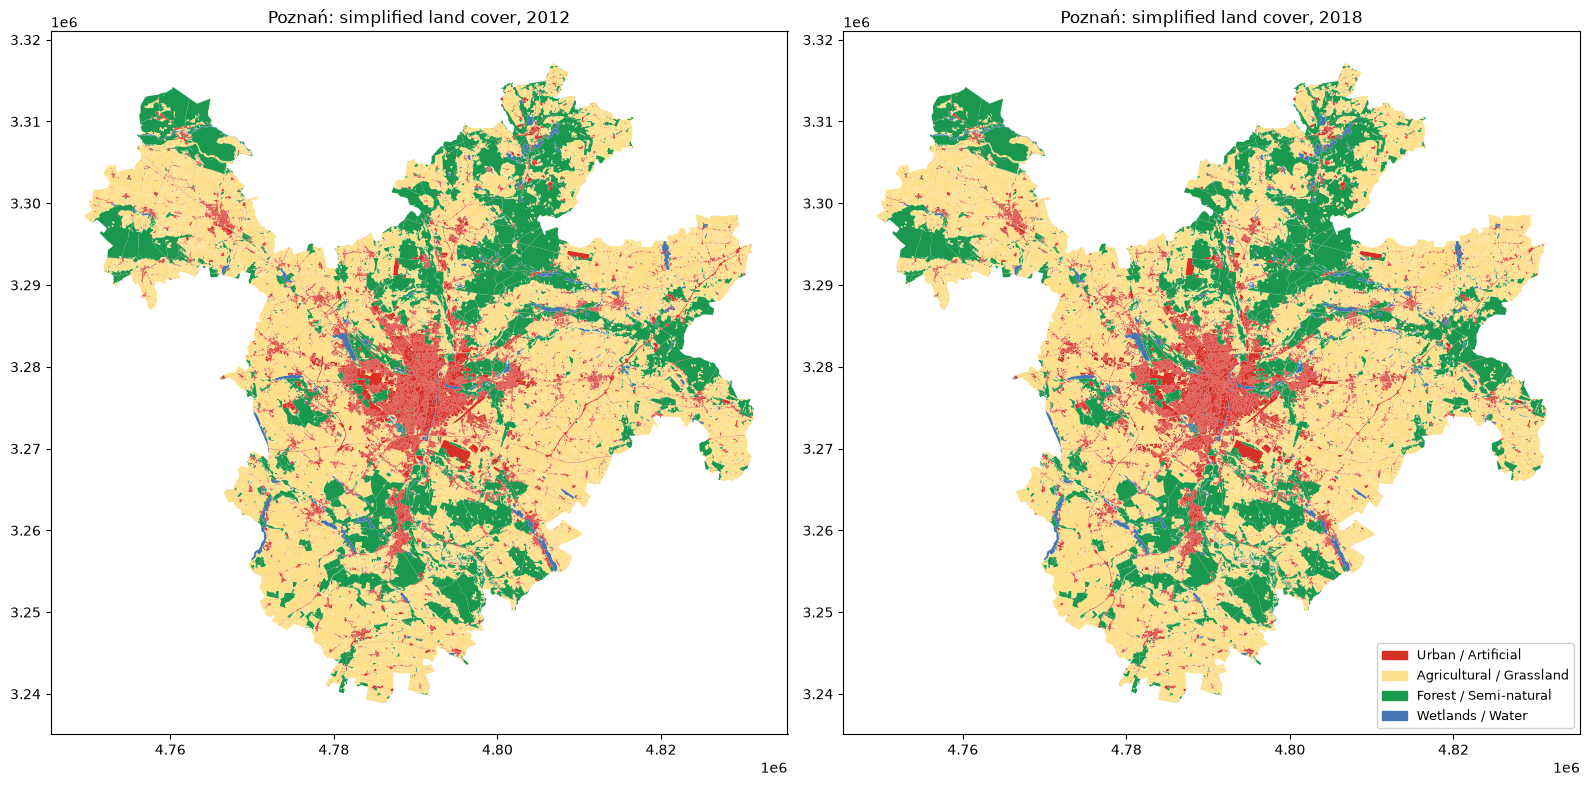

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

gdf_2012.plot(ax=ax1, column="class_simple", cmap=cmap_simple_classes)
ax1.set_title("Poznań: simplified land cover, 2012")

gdf_2018.plot(ax=ax2, column="class_simple", cmap=cmap_simple_classes)
ax2.set_title("Poznań: simplified land cover, 2018")

legend_elements = [
    mpatches.Patch(color="#d73027", label="Urban / Artificial"),
    mpatches.Patch(color="#fee08b", label="Agricultural / Grassland"),
    mpatches.Patch(color="#1a9850", label="Forest / Semi-natural"),
    mpatches.Patch(color="#4575b4", label="Wetlands / Water"),
]
ax2.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    fontsize=9,
)

plt.tight_layout()
plt.show()


Visually, this already gives a sense of the growth of the urban footprint (in red). But maps of absolute land cover are not ideal to precisely quantify **transitions**: to do that, we need to compare the two years pixel by pixel, which means converting our vector polygons into a common raster grid. This is exactly what the `geocube` package does.

In [18]:
!pip install geocube --quiet

In [19]:
from geocube.api.core import make_geocube

We rasterize both years on the same 100 m grid, using our numeric `class_code_map` (1 = Urban, 2 = Agricultural, 3 = Forest, 4 = Wetlands/Water) defined in [Section 2.2](#2.2-Utility-functions).

In [20]:
# Adding the numeric class code to each GeoDataFrame, ready for rasterization
gdf_2012["code_num"] = gdf_2012["class_simple"].map(class_code_map)
gdf_2018["code_num"] = gdf_2018["class_simple"].map(class_code_map)

In [21]:
# Rasterizing the 2012 layer onto a 100 m grid
grid_2012 = make_geocube(
    vector_data=gdf_2012,
    measurements=["code_num"],
    resolution=(-100, 100),
)

In [22]:
# Rasterizing the 2018 layer onto the same 100 m grid
grid_2018 = make_geocube(
    vector_data=gdf_2018,
    measurements=["code_num"],
    resolution=(-100, 100),
)

With both years now stored as arrays sharing the exact same grid, we can flatten and compare them pixel by pixel to build the transition matrix.

In [23]:
# Flattening both grids to 1D arrays of class codes
r2012 = grid_2012.code_num.values.flatten()
r2018 = grid_2018.code_num.values.flatten()

In [24]:
# Masking out NoData / NaN pixels (outside the Urban Atlas coverage)
mask = (~np.isnan(r2012)) & (~np.isnan(r2018)) & (r2012 > 0) & (r2018 > 0)

In [25]:
# Cross-tabulating: each cell (i, j) counts pixels that were class i in 2012
# and became class j in 2018. At 100 m resolution, 1 pixel = 1 hectare.
pixel_to_ha = 1
matrix_count = pd.crosstab(r2012[mask].astype(int), r2018[mask].astype(int))
matrix_ha = matrix_count * pixel_to_ha

# Replacing numeric codes with readable class labels on both axes
labels = [
    k for k, v in sorted(class_code_map.items(), key=lambda x: x[1]) if v in matrix_ha.index
]
matrix_ha.index = labels
matrix_ha.columns = labels

In [26]:
# Styling the transition matrix for a nicer display in the notebook
matrix_stylized = (
    matrix_ha.style.background_gradient(cmap="Blues", axis=None)
    .format("{:,.1f} ha")
    .set_caption("<b>Land-cover transition matrix, 2012 to 2018 (Poznań)</b>")
    .set_table_styles(
        [
            {"selector": "caption", "props": [("color", "#2c3e50"), ("font-size", "16px"), ("text-align", "center")]},
            {"selector": "th", "props": [("background-color", "#f4f6f7"), ("color", "#333"), ("font-weight", "bold")]},
        ]
    )
)

matrix_stylized

,1. Urban / Artificial,2. Agricultural / Grassland,3. Forest / Semi-natural,4. Wetlands / Water
1. Urban / Artificial,"43,337.0 ha",293.0 ha,85.0 ha,54.0 ha
2. Agricultural / Grassland,"2,835.0 ha","179,534.0 ha",3.0 ha,110.0 ha
3. Forest / Semi-natural,139.0 ha,5.0 ha,"77,594.0 ha",13.0 ha
4. Wetlands / Water,15.0 ha,11.0 ha,4.0 ha,"5,269.0 ha"


The diagonal of this matrix tells us how much land *stayed* in the same class between 2012 and 2018: this is the vast majority of the territory. The off-diagonal cells are the transitions we are really after: how many hectares of agricultural land or forest became urban, and vice-versa.

To locate **where** these transitions happened, we now build a transition raster that highlights only the pixels that changed class, overlaid on the 2012 background map.

In [27]:
r2012_2d = grid_2012.code_num.values
r2018_2d = grid_2018.code_num.values

# We start with an all-NaN raster: stable pixels will stay transparent
raster_trans_clean = np.full_like(r2012_2d, fill_value=np.nan, dtype=float)

# Detecting pixels whose class changed between 2012 and 2018
changed = (r2012_2d != r2018_2d) & (~np.isnan(r2012_2d)) & (~np.isnan(r2018_2d))

In [28]:
import xarray as xr

# Coding the transitions we care about most:
# 1 = Agricultural -> Urban, 2 = Forest -> Urban, 3 = gain of vegetation, 4 = other transitions
raster_trans_clean[changed & (r2012_2d == 2) & (r2018_2d == 1)] = 1
raster_trans_clean[changed & (r2012_2d == 3) & (r2018_2d == 1)] = 2
raster_trans_clean[changed & (r2018_2d == 3)] = 3
raster_trans_clean[changed & np.isnan(raster_trans_clean) & (~np.isnan(r2012_2d))] = 4

da_trans_clean = xr.DataArray(
    raster_trans_clean, coords=grid_2012.code_num.coords, dims=grid_2012.code_num.dims
)

In [29]:
# Background palette: 2012 land cover, softened with transparency
cmap_2012 = cmap_simple_classes

# Transition palette: transparent where nothing changed (np.nan)
cmap_trans = ListedColormap(["#e41a1c", "#984ea3", "#4daf4a", "#ff7f00"])
cmap_trans.set_bad(color="none", alpha=0.0)

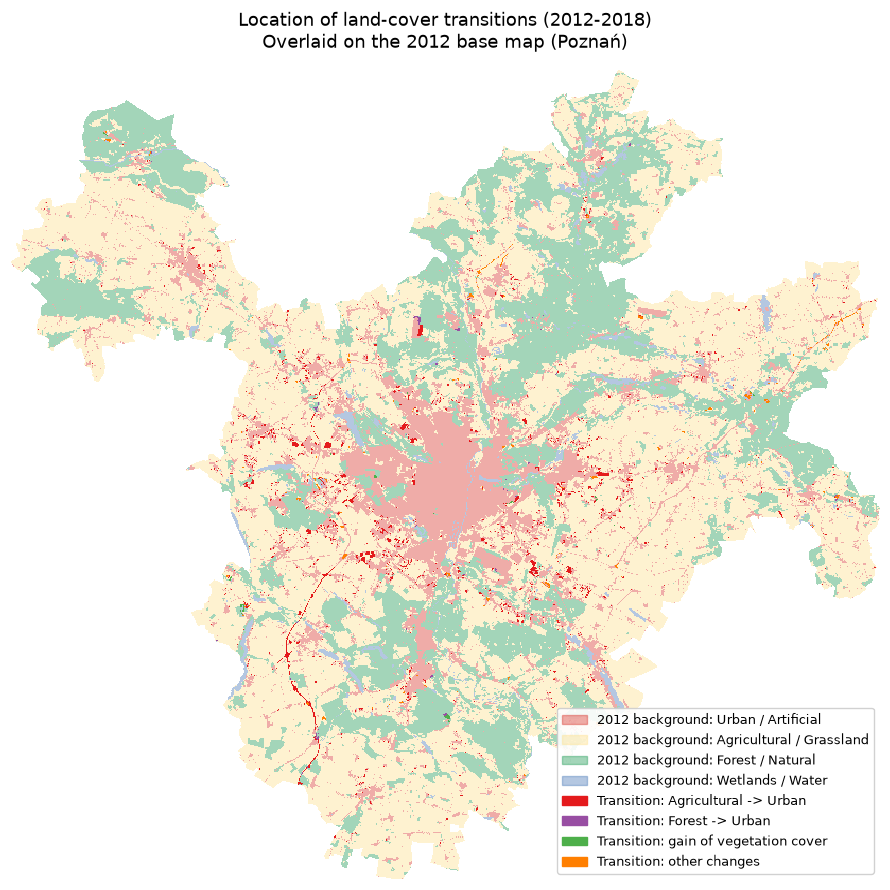

In [30]:
fig, ax = plt.subplots(figsize=(9, 9))

# Background: 2012 land cover
grid_2012.code_num.plot(ax=ax, cmap=cmap_2012, vmin=0.5, vmax=4.5, alpha=0.4, add_colorbar=False)

# Foreground: transitions only (stable pixels stay transparent)
da_trans_clean.plot(ax=ax, cmap=cmap_trans, vmin=0.5, vmax=4.5, add_colorbar=False)
ax.set_axis_off()

legend_elements = [
    mpatches.Patch(color="#d73027", alpha=0.4, label="2012 background: Urban / Artificial"),
    mpatches.Patch(color="#fee08b", alpha=0.4, label="2012 background: Agricultural / Grassland"),
    mpatches.Patch(color="#1a9850", alpha=0.4, label="2012 background: Forest / Natural"),
    mpatches.Patch(color="#4575b4", alpha=0.4, label="2012 background: Wetlands / Water"),
    mpatches.Patch(color="#e41a1c", label="Transition: Agricultural -> Urban"),
    mpatches.Patch(color="#984ea3", label="Transition: Forest -> Urban"),
    mpatches.Patch(color="#4daf4a", label="Transition: gain of vegetation cover"),
    mpatches.Patch(color="#ff7f00", label="Transition: other changes"),
]
ax.legend(handles=legend_elements, loc="lower right", frameon=True, facecolor="white", framealpha=0.9, fontsize=9)

ax.set_title(
    "Location of land-cover transitions (2012-2018)\nOverlaid on the 2012 base map (Poznań)",
    fontsize=13,
    pad=15,
)

plt.tight_layout()
plt.show()

The map of artificialized areas is done! We now know both *how much* land was converted around Poznań and *where*. Let's move on to look at the consequences of this artificialization on the landscape itself, starting with fragmentation.

## 6. Landscape fragmentation indicators

[Go back to the "Table of contents"](#Table-of-contents)

Artificialization does not only remove surface area from natural and agricultural classes, it also **fragments** what remains, cutting large contiguous patches into smaller, more isolated ones. To quantify this, we count the number of separate patches for a given class, and their average size, in 2012 and in 2018.

In [31]:
def compute_fragmentation(grid_2012, grid_2018, code, name):
    """Count connected patches and their average size (ha) for a given class code."""
    m12 = grid_2012.code_num.values == code
    m18 = grid_2018.code_num.values == code
    s = np.ones((3, 3), dtype=int)

    l12, n12 = label(m12, structure=s)
    l18, n18 = label(m18, structure=s)

    sz12 = np.bincount(l12.ravel())[1:]
    sz18 = np.bincount(l18.ravel())[1:]

    return {
        "Class": name,
        "Patches 2012": n12,
        "Patches 2018": n18,
        "Change (N patches)": f"{n18 - n12:+d}",
        "Mean size 2012": f"{np.mean(sz12):.1f} ha",
        "Mean size 2018": f"{np.mean(sz18):.1f} ha",
    }

In [32]:
df_fragmentation = pd.DataFrame(
    [
        compute_fragmentation(grid_2012, grid_2018, 2, "2. Agricultural / Grassland"),
        compute_fragmentation(grid_2012, grid_2018, 3, "3. Forest / Semi-natural"),
    ]
)

print("=== FRAGMENTATION ANALYSIS - POZNAŃ METROPOLITAN AREA ===")
print(df_fragmentation.to_string(index=False))

=== FRAGMENTATION ANALYSIS - POZNAŃ METROPOLITAN AREA ===
                      Class  Patches 2012  Patches 2018 Change (N patches) Mean size 2012 Mean size 2018
2. Agricultural / Grassland           815           885                +70       223.9 ha       203.2 ha
   3. Forest / Semi-natural           999          1015                +16        77.8 ha        76.5 ha


An increase in the number of patches, combined with a decrease in their mean size, is the classic signature of fragmentation: even where surface area losses look modest, sprawl often carves up what remains into smaller, more isolated pieces, with direct consequences on the species that depend on them.

## 7. Ecological connectivity: modelling the green network

[Go back to the "Table of contents"](#Table-of-contents)

To go one step further than counting patches, we build a simple **connectivity graph**: every sufficiently large forest patch (≥ 50 ha, a rough proxy for a "reservoir" that can sustain a resident population of forest species) becomes a node, and we draw an edge between two reservoirs if they are close enough (here, within 5 km) for species to plausibly move between them.

We build this graph for 2018 first, then for 2012, so that we can compare the two networks.

### 7.1 Forest patches and connectivity graph (2018)

In [33]:
# Identifying forest patches (class 3) in the 2018 grid
foret_2018 = grid_2018.code_num.values == 3
struct = np.ones((3, 3), dtype=int)
labeled_foret_2018, num_features_2018 = label(foret_2018, structure=struct)

# 1 pixel = 1 ha at 100 m resolution
sizes_ha_2018 = np.bincount(labeled_foret_2018.ravel()) * 1.0

# Keeping only "reservoir" patches: at least 50 ha
reservoir_ids_2018 = np.where(sizes_ha_2018 >= 50)[0]
reservoir_ids_2018 = reservoir_ids_2018[reservoir_ids_2018 != 0]

In [49]:
# Converting patch centroids (in pixel coordinates) to real-world coordinates
x_coords_2018 = grid_2018.x.values
y_coords_2018 = grid_2018.y.values

centroids_pix_2018 = center_of_mass(foret_2018, labeled_foret_2018, reservoir_ids_2018)

nodes_pos_2018 = {}
for r_id, (r_idx, c_idx) in zip(reservoir_ids_2018, centroids_pix_2018):
    geo_x = x_coords_2018[int(c_idx)]
    geo_y = y_coords_2018[int(r_idx)]
    nodes_pos_2018[r_id] = (geo_x, geo_y)

In [54]:
# Building the NetworkX graph: one node per reservoir, one edge per pair within 5 km
G_2018 = nx.Graph()

for r_id in reservoir_ids_2018:
    G_2018.add_node(r_id, surface_ha=sizes_ha_2018[r_id], pos=nodes_pos_2018[r_id])

coords_2018 = np.array([nodes_pos_2018[r_id] for r_id in reservoir_ids_2018])
dist_matrix_2018 = cdist(coords_2018, coords_2018)  # distances in meters

max_dispersion_dist = 5000  # 5 km
for i, r_id1 in enumerate(reservoir_ids_2018):
    for j, r_id2 in enumerate(reservoir_ids_2018):
        if i < j and dist_matrix_2018[i, j] <= max_dispersion_dist:
            G_2018.add_edge(r_id1, r_id2, weight=dist_matrix_2018[i, j] / 1000)

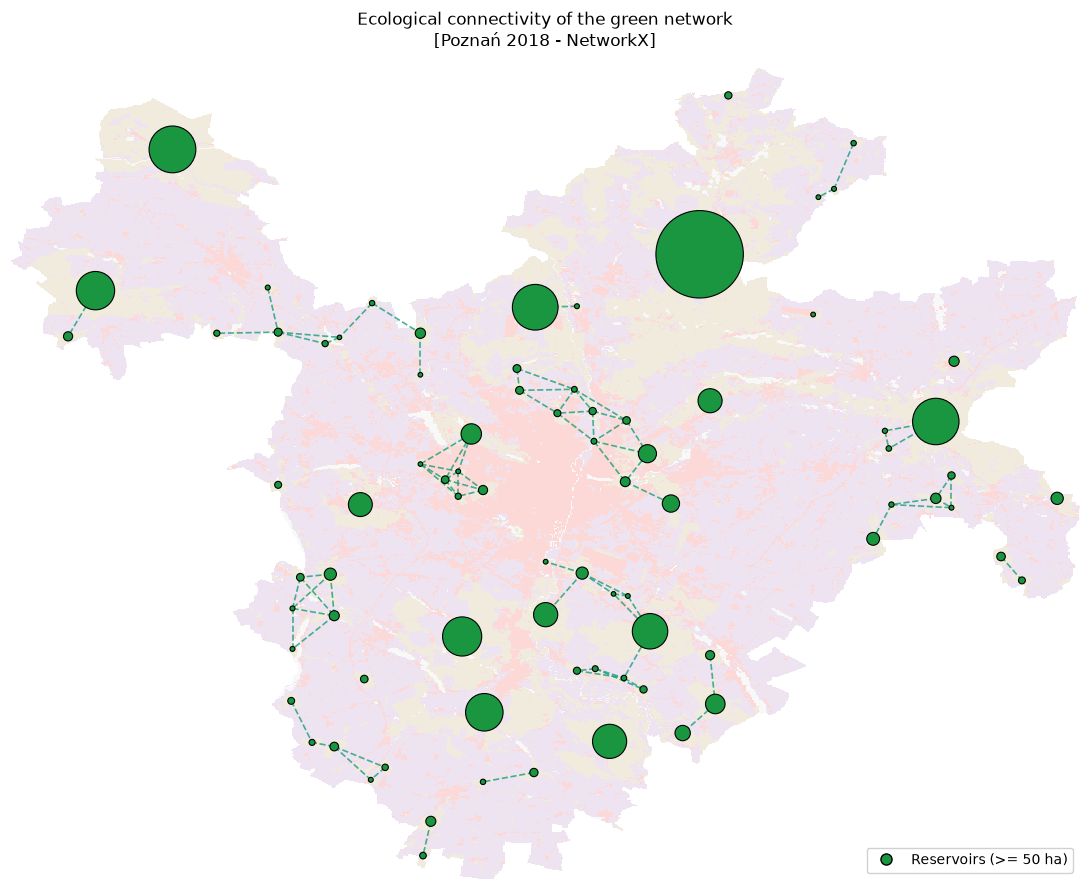

In [55]:
fig, ax = plt.subplots(figsize=(11, 9))

# Background: 2018 land cover
grid_2018.code_num.plot(ax=ax, cmap="Pastel1", add_colorbar=False, alpha=0.5)

# Corridors (graph edges)
for u, v in G_2018.edges():
    x1, y1 = nodes_pos_2018[u]
    x2, y2 = nodes_pos_2018[v]
    ax.plot([x1, x2], [y1, y2], color="#1b9e77", linestyle="--", linewidth=1.2, alpha=0.8, zorder=3)

# Reservoirs (graph nodes)
x_nodes = [pos[0] for pos in nodes_pos_2018.values()]
y_nodes = [pos[1] for pos in nodes_pos_2018.values()]
node_sizes = [sizes_ha_2018[r_id] / 5 for r_id in reservoir_ids_2018]

ax.scatter(x_nodes, y_nodes, s=node_sizes, c="#1a9641", edgecolors="black", linewidth=0.8, zorder=4, label="Reservoirs (> 50 ha)")
ax.set_axis_off()

ax.set_title("Ecological connectivity of the green network\n[Poznań 2018 - NetworkX]", fontsize=12, pad=15)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Reservoirs (>= 50 ha)',
        markerfacecolor='#1a9641',
        markeredgecolor='black',
        markersize=8,
    )
]

ax.legend(
    handles=legend_elements,
    loc='lower right',
    frameon=True,
    facecolor='white',
    framealpha=0.9,
)
plt.tight_layout()
plt.show()

In [56]:
n_components_2018 = nx.number_connected_components(G_2018)
density_2018 = nx.density(G_2018)

print("=== ECOLOGICAL CONNECTIVITY INDICATORS (POZNAŃ 2018) ===")
print(f"- Number of isolated forest sub-networks: {n_components_2018}")
print(f"- Network connection density: {density_2018:.3f}")

=== ECOLOGICAL CONNECTIVITY INDICATORS (POZNAŃ 2018) ===
- Number of isolated forest sub-networks: 28
- Network connection density: 0.025


### 7.2 Forest patches and connectivity graph (2012)

[Go back to the "Table of contents"](#Table-of-contents)

We repeat the exact same procedure on the 2012 grid, so we can compare the resulting network with the one obtained for 2018.

In [57]:
foret_2012 = grid_2012.code_num.values == 3
labeled_foret_2012, num_features_2012 = label(foret_2012, structure=struct)

sizes_ha_2012 = np.bincount(labeled_foret_2012.ravel()) * 1.0

reservoir_ids_2012 = np.where(sizes_ha_2012 >= 50)[0]
reservoir_ids_2012 = reservoir_ids_2012[reservoir_ids_2012 != 0]

In [58]:
x_coords_2012 = grid_2012.x.values
y_coords_2012 = grid_2012.y.values

centroids_pix_2012 = center_of_mass(foret_2012, labeled_foret_2012, reservoir_ids_2012)

nodes_pos_2012 = {}
for r_id, (r_idx, c_idx) in zip(reservoir_ids_2012, centroids_pix_2012):
    geo_x = x_coords_2012[int(c_idx)]
    geo_y = y_coords_2012[int(r_idx)]
    nodes_pos_2012[r_id] = (geo_x, geo_y)

In [59]:
G_2012 = nx.Graph()

for r_id in reservoir_ids_2012:
    G_2012.add_node(r_id, surface_ha=sizes_ha_2012[r_id], pos=nodes_pos_2012[r_id])

coords_2012 = np.array([nodes_pos_2012[r_id] for r_id in reservoir_ids_2012])
dist_matrix_2012 = cdist(coords_2012, coords_2012)

for i, r_id1 in enumerate(reservoir_ids_2012):
    for j, r_id2 in enumerate(reservoir_ids_2012):
        if i < j and dist_matrix_2012[i, j] <= max_dispersion_dist:
            G_2012.add_edge(r_id1, r_id2, weight=dist_matrix_2012[i, j] / 1000)

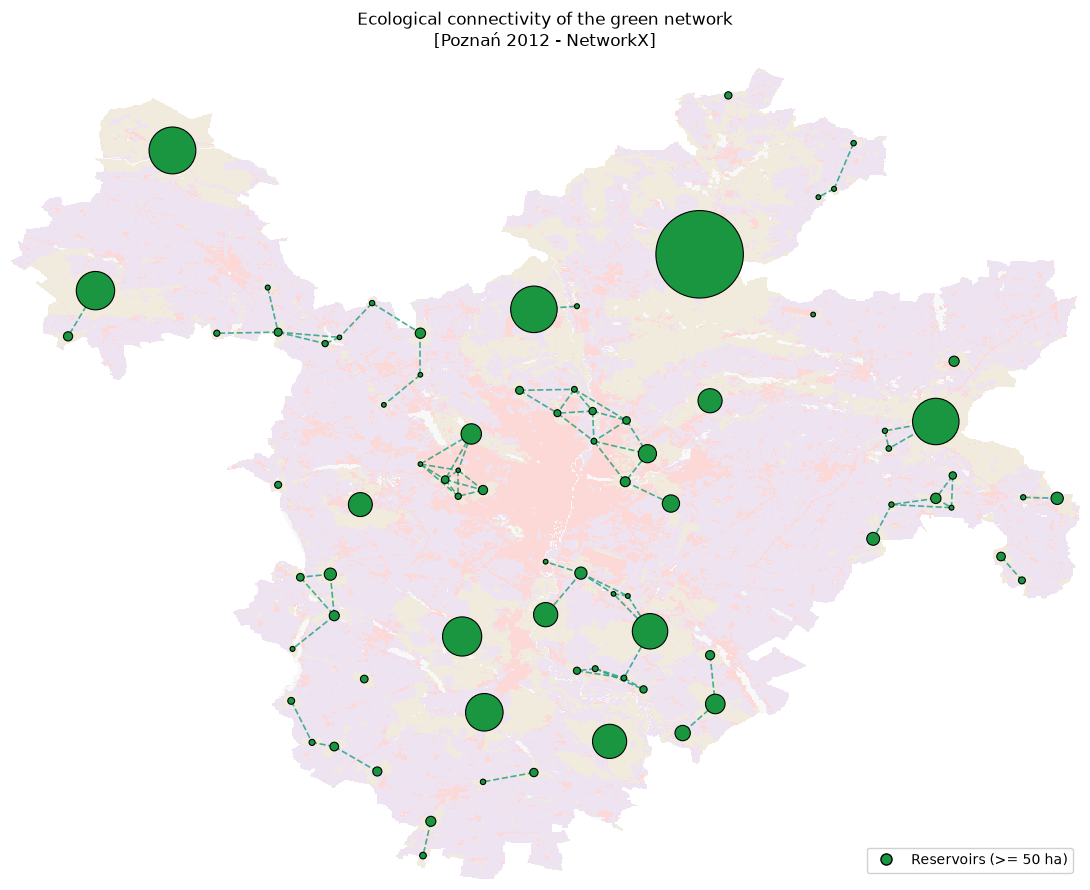

In [60]:
fig, ax = plt.subplots(figsize=(11, 9))

grid_2012.code_num.plot(ax=ax, cmap="Pastel1", add_colorbar=False, alpha=0.5)

for u, v in G_2012.edges():
    x1, y1 = nodes_pos_2012[u]
    x2, y2 = nodes_pos_2012[v]
    ax.plot([x1, x2], [y1, y2], color="#1b9e77", linestyle="--", linewidth=1.2, alpha=0.8, zorder=3)

x_nodes = [pos[0] for pos in nodes_pos_2012.values()]
y_nodes = [pos[1] for pos in nodes_pos_2012.values()]
node_sizes = [sizes_ha_2012[r_id] / 5 for r_id in reservoir_ids_2012]

ax.scatter(x_nodes, y_nodes, s=node_sizes, c="#1a9641", edgecolors="black", linewidth=0.8, zorder=4, label="Reservoirs (> 50 ha)")
ax.set_axis_off()

ax.set_title("Ecological connectivity of the green network\n[Poznań 2012 - NetworkX]", fontsize=12, pad=15)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Reservoirs (>= 50 ha)',
        markerfacecolor='#1a9641',
        markeredgecolor='black',
        markersize=8,
    )
]

ax.legend(
    handles=legend_elements,
    loc='lower right',
    frameon=True,
    facecolor='white',
    framealpha=0.9,
)

plt.tight_layout()
plt.show()

In [61]:
n_components_2012 = nx.number_connected_components(G_2012)
density_2012 = nx.density(G_2012)

print("=== ECOLOGICAL CONNECTIVITY INDICATORS (POZNAŃ 2012) ===")
print(f"- Number of isolated forest sub-networks: {n_components_2012}")
print(f"- Network connection density: {density_2012:.3f}")

=== ECOLOGICAL CONNECTIVITY INDICATORS (POZNAŃ 2012) ===
- Number of isolated forest sub-networks: 28
- Network connection density: 0.024


After computing the ecological connectivity for both 2018 and 2012, we can observe that the two urban atlases show very similar characteristics. In the next section, we refine the connectivity model by adding additional impacts of urbanization on biodiversity reservoirs, in order to better highlight potential changes between 2012 and 2018.

### 7.3 Weighting the corridors

[Go back to the "Table of contents"](#Table-of-contents)

So far, corridors are only defined by straight-line distance. In reality, a corridor that crosses a large urbanized area is much harder for wildlife to use than one crossing open fields. We therefore build a simple **friction (cost) surface**, assigning a resistance value to each land-cover class, and use it to compute an actual "cost of crossing" for every corridor of the 2018 graph, both in 2012 and in 2018.

In [62]:
# Friction (resistance) values per class: higher = harder to cross
friction_map = {
    1: 100.0,  # Urban / sealed surfaces (major barrier)
    2: 5.0,    # Agricultural / grassland (moderate friction)
    3: 1.0,    # Forest / natural (minimal friction)
    4: 20.0,   # Wetlands / water (moderate-to-high friction)
}


def code_to_friction(val):
    return friction_map.get(int(val) if not np.isnan(val) else 3, 1.0)


vf_friction = np.vectorize(code_to_friction, otypes=[float])

cost_grid_2012 = vf_friction(grid_2012.code_num.values)
cost_grid_2018 = vf_friction(grid_2018.code_num.values)

In [63]:
def compute_corridor_cost(p1_rc, p2_rc, cost_grid):
    """Sum the friction values sampled along a straight line between two (row, col) points."""
    r1, c1 = p1_rc
    r2, c2 = p2_rc

    num_samples = max(int(np.hypot(r2 - r1, c2 - c1)), 2)

    rows = np.linspace(r1, r2, num_samples).astype(int)
    cols = np.linspace(c1, c2, num_samples).astype(int)

    rows = np.clip(rows, 0, cost_grid.shape[0] - 1)
    cols = np.clip(cols, 0, cost_grid.shape[1] - 1)

    profile = cost_grid[rows, cols]
    return float(np.sum(profile))

In [64]:
# For every corridor of the 2018 graph, we compute its crossing cost both in
# 2012 and in 2018, using the same pair of endpoints (in pixel coordinates).
cost_2012 = []
cost_2018 = []

y_vals = grid_2018.y.values
x_vals = grid_2018.x.values

for u, v in G_2018.edges():
    x1, y1 = nodes_pos_2018[u]
    x2, y2 = nodes_pos_2018[v]

    r1 = int(np.argmin(np.abs(y_vals - y1)))
    c1 = int(np.argmin(np.abs(x_vals - x1)))
    r2 = int(np.argmin(np.abs(y_vals - y2)))
    c2 = int(np.argmin(np.abs(x_vals - x2)))

    c12 = compute_corridor_cost((r1, c1), (r2, c2), cost_grid_2012)
    c18 = compute_corridor_cost((r1, c1), (r2, c2), cost_grid_2018)

    cost_2012.append(c12)
    cost_2018.append(c18)

arr_12 = np.array(cost_2012)
arr_18 = np.array(cost_2018)

### 7.4 Corridor cost evolution 2012 → 2018 and degraded vs. stable corridors

[Go back to the "Table of contents"](#Table-of-contents)

In [65]:
diff_ratio = (arr_18 - arr_12) / arr_12

degraded_corridors = []
stable_corridors = []

for idx, (u, v) in enumerate(G_2018.edges()):
    ratio = diff_ratio[idx]
    if ratio > 0.02:  # crossing cost increased by more than +2%
        degraded_corridors.append((u, v))
    else:
        stable_corridors.append((u, v))

In [66]:
df_impact = pd.DataFrame(
    {
        "Green network indicator": [
            "Mean corridor crossing cost",
            "Total cumulative network resistance",
            "Corridors degraded by sprawl (> +2% cost)",
            "Stable or improved corridors",
        ],
        "2012": [f"{np.mean(arr_12):.1f}", f"{np.sum(arr_12):.1f}", "0", f"{len(G_2018.edges())}"],
        "2018": [
            f"{np.mean(arr_18):.1f}",
            f"{np.sum(arr_18):.1f}",
            f"{len(degraded_corridors)}",
            f"{len(stable_corridors)}",
        ],
    }
)

print("=== CORRIDOR RESISTANCE EVOLUTION IN POZNAŃ (2012-2018) ===")
print(df_impact.to_string(index=False))

=== CORRIDOR RESISTANCE EVOLUTION IN POZNAŃ (2012-2018) ===
                  Green network indicator    2012    2018
              Mean corridor crossing cost   640.3   645.9
      Total cumulative network resistance 51865.0 52316.0
Corridors degraded by sprawl (> +2% cost)       0      10
             Stable or improved corridors      81      71


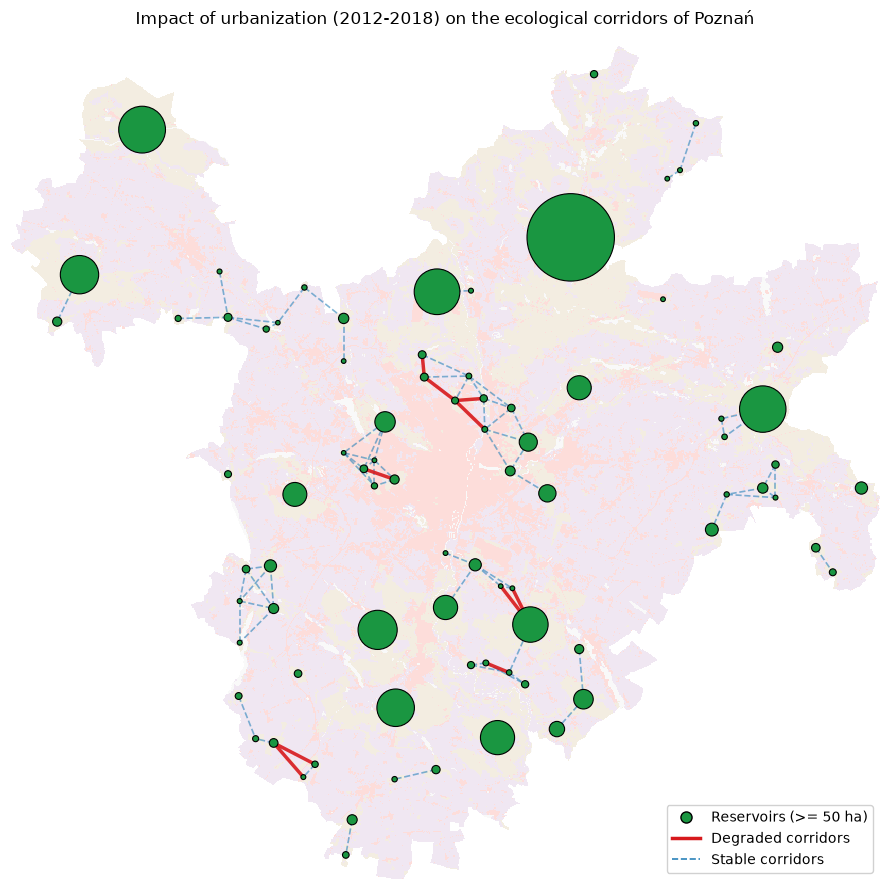

In [67]:
fig, ax = plt.subplots(figsize=(9, 9))

grid_2018.code_num.plot(ax=ax, cmap="Pastel1", add_colorbar=False, alpha=0.45)

# Stable corridors
for u, v in stable_corridors:
    x1, y1 = nodes_pos_2018[u]
    x2, y2 = nodes_pos_2018[v]
    ax.plot([x1, x2], [y1, y2], color="#2b83ba", linestyle="--", linewidth=1.2, alpha=0.6, zorder=3)

# Degraded corridors
for u, v in degraded_corridors:
    x1, y1 = nodes_pos_2018[u]
    x2, y2 = nodes_pos_2018[v]
    ax.plot([x1, x2], [y1, y2], color="#d7191c", linestyle="-", linewidth=2.5, alpha=0.9, zorder=4)

x_nodes = [pos[0] for pos in nodes_pos_2018.values()]
y_nodes = [pos[1] for pos in nodes_pos_2018.values()]
node_sizes = [sizes_ha_2018[r_id] / 5 for r_id in reservoir_ids_2018]

ax.scatter(x_nodes, y_nodes, s=node_sizes, c="#1a9641", edgecolors="black", linewidth=0.8, zorder=5, label="Reservoirs (> 50 ha)")
ax.set_axis_off()

ax.plot([], [], color="#d7191c", linestyle="-", linewidth=2.5, label="Degraded corridors (cost +)")
ax.plot([], [], color="#2b83ba", linestyle="--", linewidth=1.2, label="Stable corridors")

ax.set_title(
    "Impact of urbanization (2012-2018) on the ecological corridors of Poznań",
    fontsize=12,
    pad=15,
)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Reservoirs (>= 50 ha)',
        markerfacecolor='#1a9641',
        markeredgecolor='black',
        markersize=8,
    ),
    Line2D(
        [0],
        [0],
        color='#d7191c',
        lw=2.5,
        linestyle='-',
        label='Degraded corridors',
    ),
    Line2D(
        [0],
        [0],
        color='#2b83ba',
        lw=1.2,
        linestyle='--',
        label='Stable corridors',
    ),
]

ax.legend(
    handles=legend_elements,
    loc='lower right',
    frameon=True,
    facecolor='white',
    framealpha=0.9,
)

plt.tight_layout()
plt.show()

Even where the forest patches themselves have not shrunk much, the corridors that connect them can already show a measurable increase in crossing cost as soon as urban development creeps into the surrounding landscape, an early warning signal that is easy to miss when only looking at surface-area statistics.

## 8. Exercises

[Go back to the "Table of contents"](#Table-of-contents)

Here is a set of exercises we propose for you to go further into the analysis. There are 3 levels depending on how much Python code you need to write to answer the questions.

**Beginners**:
- In [Section 5](#5.-Mapping-land-cover-change-(2012-to-2018)), we mapped the transitions between only 4 broad simplified classes. Try adapting `map_ua_code_to_class` to create a 5th or 6th class (for example, separating "Agricultural land" from "Grassland/Pasture"), and redo the comparison maps.
- In [Section 4](#4.-Preparing-the-Urban-Atlas-datasets), we computed the total surface area per class. Try turning this into a bar chart showing the 2012 vs. 2018 surfaces side by side for each class.

**Intermediate**:
- In [Section 6](#6.-Landscape-fragmentation-indicators), we computed fragmentation only for the agricultural and forest classes. Can you compute the same indicators for the urban class? What does an increase in the number of urban patches, combined with a decrease in their average size, tell you about the *type* of urban growth (compact vs. scattered)?
- In [Section 7](#7.-Ecological-connectivity:-modelling-the-green-network), the connectivity graph only connects reservoirs within 5 km of each other. Try changing `max_dispersion_dist` to 2 km or 10 km. How does the number of connected components change?

**Experts**:
- Combine the Urban Atlas transition matrix ([Section 5](#5.-Mapping-land-cover-change-(2012-to-2018))) with the friction-based corridor analysis ([Section 7.3](#7.3-Weighting-the-corridors)): can you identify which specific transitions (e.g. Agricultural → Urban vs. Forest → Urban) contribute the most to the degradation of the most heavily used corridors?

## 9. MCQ
[Go back to the "Table of contents"](#Table-of-contents)

The practical exercises are now complete. It is time to assess your understanding of the concepts covered in this tutorial by taking a short multiple-choice quiz (MCQ). To begin, simply run the following Python cell. There is no need to understand the code at this stage, the cell will automatically launch the quiz.

In [68]:
import ipywidgets as widgets

import MCQ

state = {"i": 0, "score": 0, "answered": False}

title = widgets.HTML("<h2>🏙️ Land Artificialization around Poznań Quiz</h2>")
question_html = widgets.HTML()
buttons_box = widgets.VBox()
feedback = widgets.Output()

ui = widgets.VBox([title, question_html, buttons_box, feedback])

display(ui)

MCQ.load_question(state, feedback, question_html, buttons_box)

## 10. Conclusion

[Go back to the "Table of contents"](#Table-of-contents)

Through this tutorial, we have built a small but complete geospatial pipeline to characterize land artificialization around the Poznań metropolitan area, based on the Urban Atlas 2012 and 2018:

- We downloaded and compared these two Urban Atlas vintages to quantify how much land changed class, and built a transition matrix to see which classes converted into which;
- We rasterized these vector layers to map where the transitions occurred;
- We measured the fragmentation of agricultural and forest patches, and modelled a simplified ecological connectivity network between forest reservoirs, showing how urban sprawl degrades corridors even before it visibly shrinks the patches themselves.

This workflow is generic: with the same Copernicus Land Monitoring Service Urban Atlas product, it can be reproduced for any other European city or Functional Urban Area, or extended in time as new reference years become available.

<div class="alert alert-block alert-success">
    <b>Congratulations!</b> You have successfully completed the tutorial on using and visualizing Copernicus Land Monitoring Service products.
<br><br>
In this tutorial, you acquired all the information you need to:

* Download Copernicus Land Monitoring Service Urban Atlas products.
* Load and manipulate vector land-cover data with GeoPandas.
* Rasterize vector layers and build a land-cover transition matrix.
* Map the spatial location of land-cover transitions.
* Compute landscape fragmentation indicators.
* Build and analyse a simplified ecological connectivity graph.

We sincerely hope that you have enjoyed the tutorial and found useful information in it. Please keep in mind that the tutorial has a progressive difficulty, moving quickly from basic elements to intermediate levels. Our intention is for all users to find useful information tailored to their level.

We understand that, for a user without prior knowledge, fully understanding all the procedures in the tutorial may be a challenge that requires some effort. However, we encourage everyone to take on the challenge, this is just the beginning of a journey towards a new understanding of urban land dynamics.

This tutorial is over but we'd love to hear from you about how we could improve it (topics, tools, storytelling, format, speed, etc). If you have any question, do not hesitate to contact us via the WEkEO chatbot in the bottom-right corner of any [WEkEO](https://www.wekeo.eu/) page.

Credit: This tutorial was created by [NOVELTIS](https://www.noveltis.fr/) under Contract with Mercator Ocean for WEkEO.

## Additional Information
---

#### Compatible Data Science Toolkits

In [ ]:
import geopandas

print(geopandas.__version__)

#### Last Modified and Tested

In [ ]:
from datetime import date

print(date.today())

<img src='https://github.com/wekeo/ai4EM_MOOC/raw/04147f290cfdcce341f819eab7ad037b95f25600/img/ai4eo_logos.jpg' alt='Logo EU Copernicus WEkEO' align='center' width='100%'></img>

[View on GitHub](https://github.com/wekeo) |
[Visit WEkEO](https://www.wekeo.eu) | [Run Notebooks on the WEkEO Workspace](https://jupyterhub.prod.wekeo2.eu/) |
[Contact helpdesk for support](mailto:support@wekeo.eu)